# Data Analysis & Processing

## Preperation

In [1]:
# Module Imports
import itertools
import os
import warnings
import datetime
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

warnings.filterwarnings('ignore')

print(f'Notebook was executed on {datetime.datetime.now()}')

Notebook was executed on 2024-01-07 15:32:39.473226


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df_1 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Heart_Logistic_Regression.csv')
df_2 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Heart_GaussianNB.csv')
df_3 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Heart_DecisionTree.csv')

df_4 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_RandomForest.csv')
df_5 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_LogisticRegression.csv')
df_6 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_KNN.csv')
df_8 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_GaussianNB.csv')
df_9 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Diabetes_DecisionTree.csv')

df_10 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Bank_RandomForest.csv')
df_11 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Bank_LogisticRegression.csv')
df_12 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_bank_KNN.csv')
df_13 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_Bank_GaussianNB.csv')
df_14 = pd.read_csv('/content/drive/MyDrive/results/emissions_full_BANK_DCT.csv')

dfs = [df_1, df_2, df_3, df_4, df_5, df_6, df_8, df_9, df_10, df_11, df_12, df_13, df_14]

Mounted at /content/drive


In [3]:
 # Definieren der Feature Typen
feature_types = {
    'Diabetes_binary': 'kategorisch',
    'HighBP': 'kategorisch',
    'HighChol': 'kategorisch',
    'CholCheck': 'kategorisch',
    'BMI': 'numerisch',
    'Smoker': 'kategorisch',
    'Stroke': 'kategorisch',
    'HeartDiseaseorAttack': 'kategorisch',
    'PhysActivity': 'kategorisch',
    'Fruits': 'kategorisch',
    'Veggies': 'kategorisch',
    'HvyAlcoholConsump': 'kategorisch',
    'AnyHealthcare': 'kategorisch',
    'NoDocbcCost': 'kategorisch',
    'GenHlth': 'numerisch',
    'MentHlth': 'numerisch',
    'PhysHlth': 'numerisch',
    'DiffWalk': 'kategorisch',
    'Sex': 'kategorisch',
    'Age': 'numerisch',
    'Education': 'numerisch',
    'Income': 'numerisch',
    'age': 'numerisch',
    'job': 'kategorisch',
    'marital': 'kategorisch',
    'education': 'kategorisch',
    'default': 'kategorisch',
    'balance': 'numerisch',
    'housing': 'kategorisch',
    'loan': 'kategorisch',
    'contact': 'kategorisch',
    'day_of_week': 'kategorisch',
    'month': 'kategorisch',
    'duration': 'numerisch',
    'pdays': 'numerisch',
    'previous': 'numerisch',
    'poutcome': 'kategorisch',
    'HeartDisease': 'kategorisch',
    'BMI': 'numerisch',
    'Smoking': 'kategorisch',
    'AlcoholDrinking': 'kategorisch',
    'Stroke': 'kategorisch',
    'PhysicalHealth': 'numerisch',
    'MentalHealth': 'numerisch',
    'DiffWalking': 'kategorisch',
    'Sex': 'kategorisch',
    'AgeCategory': 'kategorisch',
    'Race': 'kategorisch',
    'Diabetic': 'kategorisch',
    'PhysicalActivity': 'kategorisch',
    'GenHealth': 'kategorisch',
    'SleepTime': 'numerisch',
    'Asthma': 'kategorisch',
    'KidneyDisease': 'kategorisch',
    'SkinCancer': 'kategorisch'
}

In [4]:
df_1.head()

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,gpu_model,longitude,latitude,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names
0,2023-11-17T08:30:09,LogisticRegression_17_features_reduced_by_0_pe...,caf57cf5-b259-4a2c-bc67-bea00e2a898c,0.445057,7.999063e-07,0.000002,42.5,0.0,4.754376,0.000005,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,0,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."
1,2023-11-17T08:30:12,LogisticRegression_17_features_reduced_by_20_p...,6ae977a5-b2fa-449c-9036-12467aec2fd5,0.365585,6.496404e-07,0.000002,42.5,0.0,4.754376,0.000004,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,20,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."
2,2023-11-17T08:30:14,LogisticRegression_17_features_reduced_by_40_p...,0830ffc0-0553-48b3-8434-e33dd6eb1be6,0.305748,5.390057e-07,0.000002,42.5,0.0,4.754376,0.000004,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,40,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."
3,2023-11-17T08:30:17,LogisticRegression_17_features_reduced_by_60_p...,6eb9c17f-25b6-4576-9073-0beaba830ad3,0.278265,4.933792e-07,0.000002,42.5,0.0,4.754376,0.000003,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,60,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."
4,2023-11-17T08:30:19,LogisticRegression_17_features_reduced_by_80_p...,9e90146c-6328-4cff-9a6e-4d6f266fa299,0.227904,3.947965e-07,0.000002,42.5,0.0,4.754376,0.000003,...,NaN,-121.1871,45.5999,12.678337,machine,N,1.0,17,80,"Smoking, BMI, Sex, Diabetic, AlcoholDrinking, ..."


In [5]:
# Mapping Features
dataframes = [df_1, df_2, df_3, df_4, df_5, df_6, df_8, df_9, df_10, df_11, df_12, df_13, df_14]

for df in dataframes:
  df['num_num_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'numerisch'))
  df['num_cat_features'] = df['feature_names'].apply(lambda x: sum(1 for feature in x.split(', ') if feature_types.get(feature) == 'kategorisch'))

# Count Features

df['feature_names'] = df['feature_names'].str.split(', ')

feature_counts = {}

for df in dataframes:
    df['feature_names'] = df['feature_names'].str.split(', ')
    for index, row in df.iterrows():
        features = row['feature_names']
        if isinstance(features, list):
            for feature in features:
                if feature in feature_counts:
                    feature_counts[feature] += 1
                else:
                    feature_counts[feature] = 1

In [6]:
# Set % Heart = 320.000 Diabetes = 250.000 Bank = 45.211

df_1['number_of_instances'] = 320000 * (1 - df_1['reduction_percentage'] / 100)
df_2['number_of_instances'] =  320000 * (1 - df_2['reduction_percentage'] / 100)
df_3['number_of_instances'] =  320000 * (1 - df_3['reduction_percentage'] / 100)

df_4['number_of_instances'] = 250000 * (1 - df_4['reduction_percentage'] / 100)
df_5['number_of_instances'] = 250000 * (1 - df_5['reduction_percentage'] / 100)
df_6['number_of_instances'] = 250000 * (1 - df_6['reduction_percentage'] / 100)
df_8['number_of_instances'] = 250000 * (1 - df_8['reduction_percentage'] / 100)
df_9['number_of_instances'] = 250000 * (1 - df_9['reduction_percentage'] / 100)

df_10['number_of_instances'] = 45211 * (1 - df_10['reduction_percentage'] / 100)
df_11['number_of_instances'] = 45211 * (1 - df_11['reduction_percentage'] / 100)
df_12['number_of_instances'] = 45211 * (1 - df_12['reduction_percentage'] / 100)
df_13['number_of_instances'] = 45211 * (1 - df_13['reduction_percentage'] / 100)
df_14['number_of_instances'] = 45211 * (1 - df_14['reduction_percentage'] / 100)

In [7]:
df_14

,timestamp,project_name,run_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,cpu_energy,...,ram_total_size,tracking_mode,on_cloud,pue,num_features,reduction_percentage,feature_names,num_num_features,num_cat_features,number_of_instances
0,2023-11-12T13:00:24,DecisionTree_19_features_reduced_by_0_percent0,b089c878-b567-4b5e-ae70-03abeaade72a,0.299119,1.504002e-06,0.000005,42.5,0.0,4.754379,3.483172e-06,...,12.678345,machine,N,1.0,19,0,NaN,3,10,45211.0
1,2023-11-12T13:00:26,DecisionTree_19_features_reduced_by_20_percent0,770b3004-eee9-4bd5-9821-dccecd4d942d,0.171267,8.497686e-07,0.000005,42.5,0.0,4.754379,1.969609e-06,...,12.678345,machine,N,1.0,19,20,NaN,3,10,36168.8
2,2023-11-12T13:00:28,DecisionTree_19_features_reduced_by_40_percent0,2b72544f-d62a-4ab4-a940-c8e159941119,0.132989,6.234077e-07,0.000005,42.5,0.0,4.754379,1.444711e-06,...,12.678345,machine,N,1.0,19,40,NaN,3,10,27126.6
3,2023-11-12T13:00:30,DecisionTree_19_features_reduced_by_60_percent0,20cb3715-3a20-479f-9b16-aa9e51ecb21f,0.093119,4.414532e-07,0.000005,42.5,0.0,4.754379,1.024619e-06,...,12.678345,machine,N,1.0,19,60,NaN,3,10,18084.4
4,2023-11-12T13:00:31,DecisionTree_19_features_reduced_by_80_percent0,a27f9f39-c84b-4842-a897-92226f7946d9,0.047154,2.168466e-07,0.000005,42.5,0.0,4.754379,5.048775e-07,...,12.678345,machine,N,1.0,19,80,NaN,3,10,9042.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,2023-11-12T13:34:26,DecisionTree_1_features_reduced_by_0_percent9,b835d9a9-1402-4846-be20-3647071ba0a0,0.034970,1.342487e-07,0.000004,42.5,0.0,4.754379,3.142431e-07,...,12.678345,machine,N,1.0,1,0,NaN,0,0,45211.0
946,2023-11-12T13:34:28,DecisionTree_1_features_reduced_by_20_percent9,5cb19a56-14e2-4cd8-b290-1cbae78be04f,0.026003,1.075331e-07,0.000004,42.5,0.0,4.754379,2.524331e-07,...,12.678345,machine,N,1.0,1,20,NaN,0,0,36168.8
947,2023-11-12T13:34:31,DecisionTree_1_features_reduced_by_40_percent9,744a02b8-f911-4afd-b21d-9dbd451513d2,0.020767,7.394801e-08,0.000004,42.5,0.0,4.754379,1.743346e-07,...,12.678345,machine,N,1.0,1,40,NaN,0,0,27126.6
948,2023-11-12T13:34:33,DecisionTree_1_features_reduced_by_60_percent9,0d6062b2-5b17-41d9-8993-30a614bac1e5,0.017998,5.181180e-08,0.000003,42.5,0.0,4.754379,1.258887e-07,...,12.678345,machine,N,1.0,1,60,NaN,0,0,18084.4


In [8]:
# Add Model
model_names = {
    'random_forest': [df_4, df_10],
    'logistic_regression': [df_1, df_5, df_11],
    'knn': [df_6, df_12],
    'gaussian_nb': [df_2, df_8, df_13],
    'decision_tree': [df_3, df_9, df_14]
}

for model_name, dfs in model_names.items():
    for df in dfs:
        df.insert(0, 'model', model_name)
        df['model'] = df['model'].astype(str)

In [9]:
df = pd.concat([df_1, df_2, df_3, df_4, df_5, df_6, df_8, df_9, df_10, df_11, df_12, df_13, df_14])

In [10]:
# Reduce Features
selected_columns = ['energy_consumed', 'num_num_features', 'num_cat_features', 'number_of_instances', 'model']

df = df[selected_columns]

In [11]:
df

,energy_consumed,num_num_features,num_cat_features,number_of_instances,model
0,5.765098e-06,4,13,320000.0,logistic_regression
1,4.682099e-06,4,13,256000.0,logistic_regression
2,3.884730e-06,4,13,192000.0,logistic_regression
3,3.555891e-06,4,13,128000.0,logistic_regression
4,2.845384e-06,4,13,64000.0,logistic_regression
...,...,...,...,...,...
945,3.453769e-07,0,0,45211.0,decision_tree
946,2.766466e-07,0,0,36168.8,decision_tree
947,1.902435e-07,0,0,27126.6,decision_tree
948,1.332944e-07,0,0,18084.4,decision_tree


In [12]:
unique_values = df['model'].unique()
print(unique_values)

['logistic_regression' 'gaussian_nb' 'decision_tree' 'random_forest' 'knn']


In [13]:
df.isna().sum()

energy_consumed        0
num_num_features       0
num_cat_features       0
number_of_instances    0
model                  0
dtype: int64

## Data Analysis

In [14]:
numerische_attribute = df.select_dtypes(include=['int64', 'float64'])

korrelationsmatrix = numerische_attribute.corr()
korrelation_mit_energy = korrelationsmatrix['energy_consumed'].sort_values(ascending=False)

korrelation_mit_energy

energy_consumed        1.000000
num_num_features       0.222802
num_cat_features       0.173120
number_of_instances    0.101449
Name: energy_consumed, dtype: float64

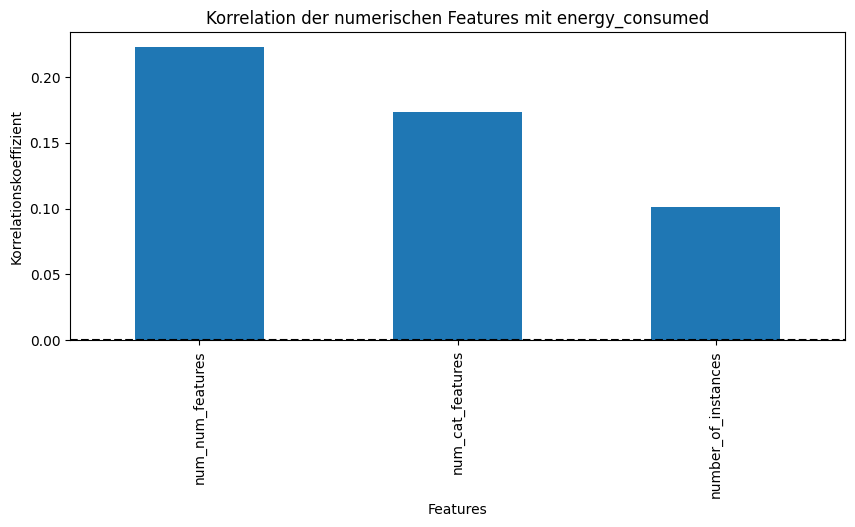

In [15]:
plt.figure(figsize=(10, 4))
korrelation_mit_energy.drop('energy_consumed').plot(kind='bar')
plt.title('Korrelation der numerischen Features mit energy_consumed')
plt.xlabel('Features')
plt.ylabel('Korrelationskoeffizient')
plt.axhline(y=0, color='k', linestyle='--')
plt.show()

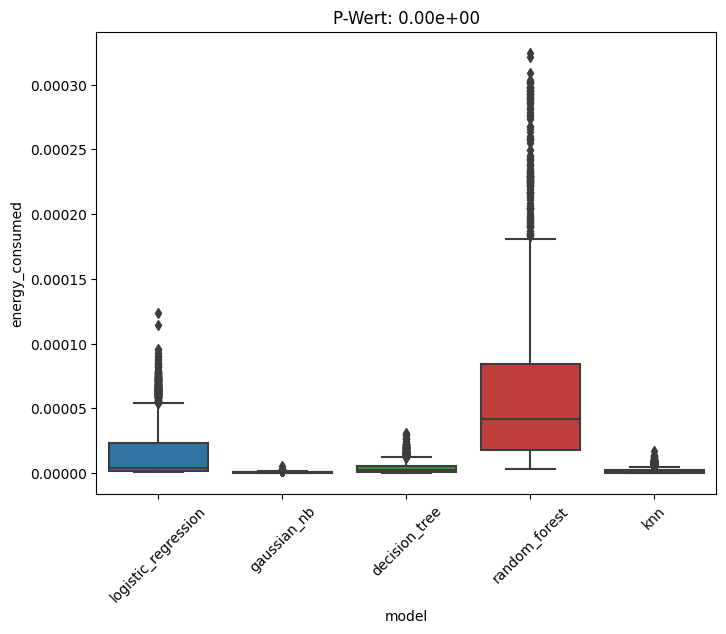

In [17]:
selected_feature = 'model'

# ANOVA-Tests
gruppen = df.groupby(selected_feature)['energy_consumed'].apply(list)
anova_ergebnis = stats.f_oneway(*gruppen)

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(x=selected_feature, y='energy_consumed', data=df, ax=ax)
ax.set_title(f'P-Wert: {anova_ergebnis.pvalue:.2e}')
ax.tick_params(axis='x', rotation=45)

plt.show()

In [18]:
def plot_categorical_feature(df, feature_name, target_column='energy_consumed', figsize=(10, 6)):
    plt.figure(figsize=figsize)

    for category in df[feature_name].unique():
        sns.histplot(df[df[feature_name] == category][target_column], kde=True, label=category)

    plt.legend(title=feature_name)
    plt.xlabel(target_column)
    plt.ylabel('Häufigkeit')
    plt.title(f'{feature_name} vs. {target_column}')
    plt.show()

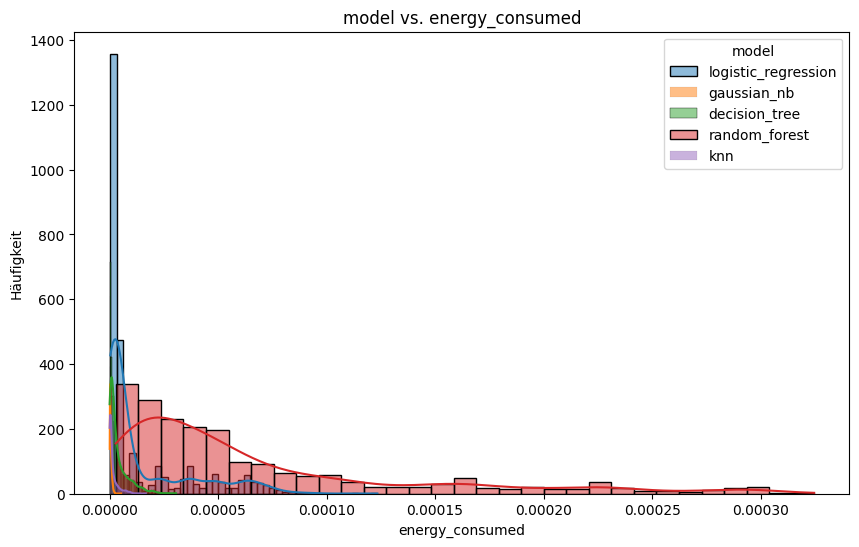

In [20]:
plot_categorical_feature(df, 'model')

## Data Pre-Processing
Das unten ist jetzt wichtig, wo müssen später im Backend die "codes" für die einzelen Modelle angegeben werden\

In [21]:
model_mapping = {
    'decision_tree': 0.0,
    'gaussian_nb': 1.0,
    'knn': 2.0,
    'logistic_regression': 3.0,
    'random_forest': 4.0
}

df['model'] = df['model'].replace(model_mapping)

In [22]:
df

,energy_consumed,num_num_features,num_cat_features,number_of_instances,model
0,5.765098e-06,4,13,320000.0,3.0
1,4.682099e-06,4,13,256000.0,3.0
2,3.884730e-06,4,13,192000.0,3.0
3,3.555891e-06,4,13,128000.0,3.0
4,2.845384e-06,4,13,64000.0,3.0
...,...,...,...,...,...
945,3.453769e-07,0,0,45211.0,0.0
946,2.766466e-07,0,0,36168.8,0.0
947,1.902435e-07,0,0,27126.6,0.0
948,1.332944e-07,0,0,18084.4,0.0


In [23]:
df.to_csv('energy_predcition_training-data.csv', index=False)